# Dealing with Categorical Variables - Lab

## Introduction

In this lab, you'll explore the Ames Housing dataset and identify numeric and categorical variables. Then you'll transform some categorical data and use it in a multiple regression model.

## Objectives

You will be able to:

* Determine whether variables are categorical or numeric
* Use one-hot encoding to create dummy variables

## Step 1: Load the Ames Housing Dataset

Import `pandas`, and use it to load the file `ames.csv` into a dataframe called `ames`. If you pass in the argument `index_col=0` this will set the "Id" feature as the index.

In [43]:
# Your code here - load the dataset
import pandas as pd
ames = pd.read_csv('ames.csv', index_col=0)

Visually inspect `ames` (it's ok if you can't see all of the columns).

In [44]:
# Your code here
ames

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


Go ahead and drop all **columns** with missing data, to simplify the problem. Remember that you can use the `dropna` method ([documentation here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)).

In [45]:
# Your code here - drop columns with missing values
ames = ames.dropna(axis=1)
ames

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,2,2008,WD,Normal,208500
2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,0,0,0,0,0,5,2007,WD,Normal,181500
3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,9,2008,WD,Normal,223500
4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,0,0,0,0,0,8,2007,WD,Normal,175000
1457,20,RL,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,0,0,0,0,0,2,2010,WD,Normal,210000
1458,70,RL,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,0,0,0,0,2500,5,2010,WD,Normal,266500


## Step 2: Identify Numeric and Categorical Variables

The file `data_description.txt`, located in this repository, has a full description of all variables.

Using this file as well as `pandas` techniques, identify the following predictors:

1. A **continuous numeric** predictor
2. A **discrete numeric** predictor
3. A **string categorical** predictor
4. A **discrete categorical** predictor

(Note that `SalePrice` is the target variable and should not be selected as a predictor.)

For each of these predictors, visualize the relationship between the predictor and `SalePrice` using an appropriate plot.

Finding these will take some digging -- don't be discouraged if they're not immediately obvious. The Ames Housing dataset is a lot more complex than the Auto MPG dataset. There is also no single right answer here.

In [57]:
# we have 34 int and 27 strings 
ames.dtypes.value_counts()

int64     34
object    27
dtype: int64

In [58]:
# numeric columns
ames.describe()

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,10516.828082,6.099315,5.575342,1971.267808,1984.865753,443.639726,46.549315,567.240411,1057.429452,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,9981.264932,1.382997,1.112799,30.202904,20.645407,456.098091,161.319273,441.866955,438.705324,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,223.000000,795.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,383.500000,0.000000,477.500000,991.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,712.250000,0.000000,808.000000,1298.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,5644.000000,1474.000000,2336.000000,6110.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [59]:
ames.select_dtypes(include='object').nunique().sort_values()

Street            2
Utilities         2
CentralAir        2
LandSlope         3
PavedDrive        3
LotShape          4
LandContour       4
KitchenQual       4
ExterQual         4
MSZoning          5
LotConfig         5
BldgType          5
HeatingQC         5
ExterCond         5
Heating           6
Foundation        6
SaleCondition     6
RoofStyle         6
Functional        7
HouseStyle        8
Condition2        8
RoofMatl          8
SaleType          9
Condition1        9
Exterior1st      15
Exterior2nd      16
Neighborhood     25
dtype: int64

### Continuous Numeric Predictor

In [60]:
# Your code here - continuous numeric predictor
numeric_cols = ames.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'SalePrice']
continuous_numeric = [col for col in numeric_cols if ames[col].nunique() > 15]
print(continuous_numeric)

['LotArea', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MiscVal']


### Discrete Numeric Predictor

In [61]:
# Your code here - discrete numeric predictor
numeric_cols = ames.select_dtypes(include=['int64', 'float64']).columns

# Discrete numeric predictors: numeric variables with few unique values
discrete_numeric_predictors = [
    col for col in numeric_cols
    if ames[col].nunique() <= 15
]

print(discrete_numeric_predictors)


['MSSubClass', 'OverallQual', 'OverallCond', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'PoolArea', 'MoSold', 'YrSold']


### String Categorical Predictor

In [56]:
# Your code here - string categorical predictor
string_categorical_predictors = ames.select_dtypes(include=['object']).columns.tolist()

print(string_categorical_predictors)


['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'Heating', 'HeatingQC', 'CentralAir', 'KitchenQual', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition']


### Discrete Categorical Predictor

In [63]:
# Your code here - discrete categorical predictor
# Select categorical columns (string/object type)
categorical_cols = ames.select_dtypes(include=['object']).columns

# Discrete categorical predictors: few unique categories
discrete_categorical_predictors = [
    col for col in categorical_cols
    if ames[col].nunique() <= 10
]

print(discrete_categorical_predictors)

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'ExterQual', 'ExterCond', 'Foundation', 'Heating', 'HeatingQC', 'CentralAir', 'KitchenQual', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition']


## Step 3: Build a Multiple Regression Model with Your Chosen Predictors

Choose the best-looking 3 out of 4 predictors to include in your model.

Make sure that you one-hot encode your categorical predictor(s) (regardless of whether the current data type is a string or number) first.

In [50]:
# Your code here - prepare X and y, including one-hot encoding
y = ames['SalePrice']
X = ames[['GrLivArea', 'OverallQual', 'Neighborhood', 'BldgType']]
X = pd.get_dummies(X, drop_first=True)




In [51]:
X.head()

,GrLivArea,OverallQual,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,...,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
Id,,,,,,,,,,,,,,,,,,,,,
1,1710,7,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1262,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,1786,7,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1717,7,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2198,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
# Your answer here - which category or categories were dropped?
#Neighborhood and BldgType were dropped during one-hot encoding because they had the 
# highest cardinality among the categorical predictors.


In [53]:
# Your code here - build a regression model and display results
import statsmodels.api as sm
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     191.3
Date:                Sat, 20 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:14:46   Log-Likelihood:                -17367.
No. Observations:                1460   AIC:                         3.480e+04
Df Residuals:                    1429   BIC:                         3.496e+04
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2932.3667   1.21e+04      0.243      0.808   -2.08e+04    2.66e+04
GrLivArea               53.1375      2.513     21.149      0.000      48.209      58.066
OverallQual            2.05e+04   1152.082     17.798      0.000    1.82e+04    2.28e+04
Neighborhood_Blueste -1.906e+04   2.71e+04     -0.704      0.481   -7.21e+04     3.4e+04
Neighborhood_BrDale  -2.722e+04   1.36e+04     -1.997      0.046    -5.4e+04    -485.178
Neighborhood_BrkSide -4.537e+04    1.1e+04     -4.137      0.000   -6.69e+04   -2.39e+04
Neighborhood_ClearCr -6211.7591   1.19e+04     -0.522      0.602   -2.96e+04    1.71e+04
Neighborhood_CollgCr -1.758e+04   9981.804     -1.762      0.078   -3.72e+04    1996.983
Neighborhood_Crawfor -1.331e+04   1.08e+04     -1.229      0.219   -3.46e+04    7943.027
Neighborhood_Edwards -4.529e+04   1.04e+04     -4.344      0.000   -6.57e+04   -2.48e+04
Neighborhood_Gilbert -3.165e+04   1.05e+04     -3.022      0.003   -5.22e+04   -1.11e+04
Neighborhood_IDOTRR  -6.013e+04   1.16e+04     -5.191      0.000   -8.29e+04   -3.74e+04
Neighborhood_MeadowV -1.073e+04   1.29e+04     -0.831      0.406    -3.6e+04    1.46e+04
Neighborhood_Mitchel -2.361e+04   1.09e+04     -2.157      0.031   -4.51e+04   -2135.565
Neighborhood_NAmes    -3.48e+04   1.01e+04     -3.445      0.001   -5.46e+04    -1.5e+04
Neighborhood_NPkVill -9904.4982    1.5e+04     -0.660      0.509   -3.93e+04    1.95e+04
Neighborhood_NWAmes  -3.492e+04   1.06e+04     -3.305      0.001   -5.56e+04   -1.42e+04
Neighborhood_NoRidge  3.651e+04   1.12e+04      3.247      0.001    1.45e+04    5.86e+04
Neighborhood_NridgHt  5.349e+04   1.02e+04      5.267      0.000    3.36e+04    7.34e+04
Neighborhood_OldTown -6.245e+04   1.04e+04     -5.997      0.000   -8.29e+04    -4.2e+04
Neighborhood_SWISU   -6.676e+04   1.22e+04     -5.462      0.000   -9.07e+04   -4.28e+04
Neighborhood_Sawyer  -3.209e+04   1.07e+04     -2.987      0.003   -5.32e+04    -1.1e+04
Neighborhood_SawyerW -2.517e+04   1.06e+04     -2.383      0.017   -4.59e+04   -4453.774
Neighborhood_Somerst  -299.7914      1e+04     -0.030      0.976   -1.99e+04    1.93e+04
Neighborhood_StoneBr  5.626e+04   1.15e+04      4.899      0.000    3.37e+04    7.88e+04
Neighborhood_Timber   -226.4536   1.13e+04     -0.020      0.984   -2.23e+04    2.19e+04
Neighborhood_Veenker   2.51e+04   1.42e+04      1.768      0.077   -2741.032    5.29e+04
BldgType_2fmCon      -6976.4503   6769.794     -1.031      0.303   -2.03e+04    6303.349
BldgType_Duplex      -1.969e+04   5299.384     -3.716      0.000   -3.01e+04   -9294.710
BldgType_Twnhs       -5.376e+04   7128.591     -7.542      0.000   -6.77e+04   -3.98e+04
BldgType_TwnhsE      -3.303e+04   4502.324     -7.336      0.000   -4.19e+04   -2.42e+04
=========================================================

## Step 4: Create Partial Regression Plots for Features

For each feature of the regression above (including the dummy features), plot the partial regression.

ValueError: num must be 1 <= num <= 8, not 9

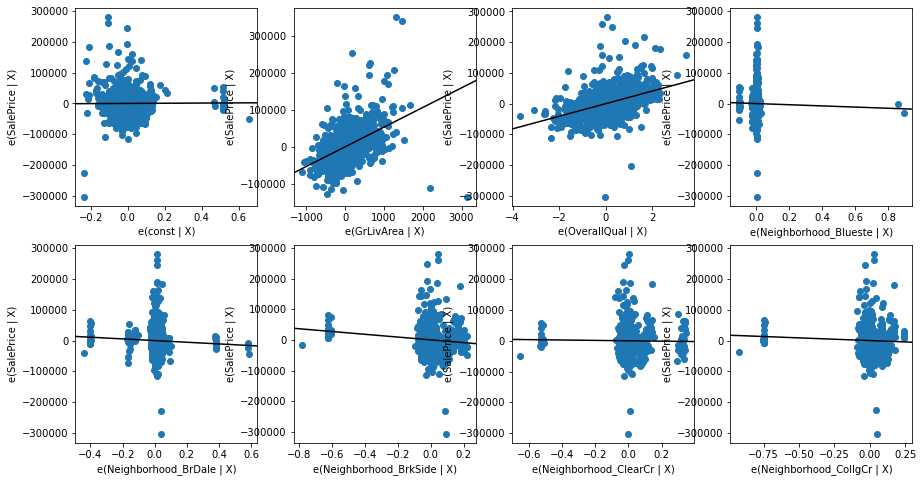

In [54]:
# Your code here - create partial regression plots
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15,8))
sm.graphics.plot_partregress_grid(
    model,
    exog_idx=list(X.columns.values),
    grid=(2,4),
    fig=fig)
plt.show()

## Step 5: Calculate an Error-Based Metric

In addition to the adjusted R-Squared that we can see in the model summary, calculate either MAE or RMSE for this model.

In [ ]:
# Your code here - calculate an error-based metric
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np



# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model on training data
model_rmse = sm.OLS(y_train, X_train).fit()

# Predict on test data
y_pred = model_rmse.predict(X_test)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse


37571.44861401883

## Step 6: Summarize Findings

Between the model results, partial regression plots, and error-based metric, what does this model tell you? What would your next steps be to improve the model?

In [ ]:
# Your answer here
#On average, the model predicts house prices are about $37,571 away from the actual sale prices.
#In the Ames dataset: Average SalePrice ≈ $180,000. The model’s typical error is about 20–22%
# of the house price. Log transforming the target variable could help improve this.

## Level Up (Optional)

Try transforming X using scikit-learn _and_ fitting a scikit-learn linear regression as well. If there are any differences in the result, investigate them.

In [ ]:
# Your code here

## Summary

In this lab, you practiced your knowledge of categorical variables on the Ames Housing dataset! Specifically, you practiced distinguishing numeric and categorical data. You then created dummy variables using one hot encoding in order to build a multiple regression model.